# Chemistry Generation Demo

This notebook is the maintained chemistry-focused Conditional Node Field demo.

It is tailored to molecular graph generation:
- it uses PubChem molecular graphs only,
- it uses molecule drawing instead of artificial graph rendering,
- it keeps edge-label supervision enabled,
- it relies on node-existence masking so generated graphs can have variable numbers of nodes.

In [1]:
# Enable inline plotting and autoreload for chemistry exploration.
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

_repo_candidates = [Path.cwd(), Path.cwd().parent]
for _root in _repo_candidates:
    if (_root / 'conditional_node_field_graph_generator').exists():
        REPO_ROOT = _root.resolve()
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise ModuleNotFoundError("Could not locate 'conditional_node_field_graph_generator'.")

_nsppk_candidates = []
if os.environ.get("NSPPK_ROOT"):
    _nsppk_candidates.append(Path(os.environ["NSPPK_ROOT"]).expanduser())
_nsppk_candidates.extend([
    REPO_ROOT / 'NSPPK',
    REPO_ROOT.parent / 'NSPPK',
    Path.cwd() / 'NSPPK',
    Path.cwd().parent / 'NSPPK',
])
for _nsppk_root in _nsppk_candidates:
    _candidate = _nsppk_root.resolve()
    if _candidate.exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise ModuleNotFoundError("Could not locate NSPPK. Set NSPPK_ROOT or clone NSPPK next to this repo.")

ARTIFACT_ROOT = REPO_ROOT / '.artifacts'
NOTEBOOK_DATA_ROOT = REPO_ROOT / 'notebooks' / 'datasets'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'checkpoints' / 'node_field'

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

PyTorch version: 2.2.2
CUDA available: False


In [2]:
# Import the molecule drawing helper used later for dataset previews and samples.
from coco_grape.visualizer.mol_display import draw_molecules


def show_molecules(graphs, n=12, title=None):
    graphs = list(graphs)[:n]
    if title:
        print(title)
    if not graphs:
        print("No graphs to display.")
        return
    draw_molecules(graphs)


def label_counter(graphs, kind="node"):
    counts = {}
    if kind == "node":
        for graph in graphs:
            for _, attrs in graph.nodes(data=True):
                label = attrs.get("label")
                counts[label] = counts.get(label, 0) + 1
    elif kind == "edge":
        for graph in graphs:
            for _, _, attrs in graph.edges(data=True):
                label = attrs.get("label")
                counts[label] = counts.get(label, 0) + 1
    else:
        raise ValueError("kind must be 'node' or 'edge'")
    return dict(sorted(counts.items(), key=lambda item: str(item[0])))


def summarize_graphs(graphs, targets=None, prefix="dataset"):
    node_counts = np.array([graph.number_of_nodes() for graph in graphs], dtype=int)
    edge_counts = np.array([graph.number_of_edges() for graph in graphs], dtype=int)
    print(f"{prefix}: {len(graphs)} graphs")
    if targets is not None:
        print(f"{prefix}: class counts = {dict(zip(*np.unique(targets, return_counts=True)))}")
    print(
        f"{prefix}: node count min/median/max = "
        f"{node_counts.min()}/{int(np.median(node_counts))}/{node_counts.max()}"
    )
    print(
        f"{prefix}: edge count min/median/max = "
        f"{edge_counts.min()}/{int(np.median(edge_counts))}/{edge_counts.max()}"
    )
    print(f"{prefix}: node labels = {label_counter(graphs, 'node')}")
    print(f"{prefix}: edge labels = {label_counter(graphs, 'edge')}")


def show_seed_and_samples(graph_generator, seed_graphs, n_seeds=6, title="Samples", apply_feasibility_filtering=None):
    # Show conditioning graphs first, then raw samples, then notebook-configured decoded samples.
    if apply_feasibility_filtering is None:
        apply_feasibility_filtering = APPLY_FEASIBILITY_FILTERING
    seed_graphs = list(seed_graphs)[:n_seeds]
    show_molecules(seed_graphs, n=n_seeds, title=f"{title}: conditioning molecules")

    raw_samples = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_seeds,
        apply_feasibility_filtering=False,
    )
    show_molecules(raw_samples, n=n_seeds, title=f"{title}: generated molecules without feasibility")

    if not apply_feasibility_filtering:
        return raw_samples

    feasible_samples = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_seeds,
        apply_feasibility_filtering=True,
    )
    show_molecules(feasible_samples, n=n_seeds, title=f"{title}: generated molecules with feasibility")
    return feasible_samples


def inspect_predicted_masks_and_edge_labels(graph_generator, graphs, n_graphs=6):
    graph_conditioning = graph_generator.graph_encode(list(graphs)[:n_graphs])
    generated_nodes = graph_generator.conditional_node_generator_model.predict(graph_conditioning)

    observed_node_counts = graph_conditioning.node_counts[:n_graphs]
    predicted_node_counts = generated_nodes.node_presence_mask[:n_graphs].sum(axis=1)
    mask_frame = pd.DataFrame(
        {
            "conditioning_nodes": observed_node_counts,
            "predicted_nodes": predicted_node_counts,
            "conditioning_edges": graph_conditioning.edge_counts[:n_graphs],
        }
    )
    display(mask_frame)

    edge_label_matrices = generated_nodes.edge_label_matrices
    if edge_label_matrices is None:
        print("No edge-label matrices were predicted.")
    else:
        summaries = []
        for idx, matrix in enumerate(edge_label_matrices[:n_graphs]):
            labels, counts = np.unique(np.asarray(matrix, dtype=object), return_counts=True)
            summaries.append({"graph_idx": idx, **{str(label): int(count) for label, count in zip(labels, counts)}})
        display(pd.DataFrame(summaries).fillna(0).astype({"graph_idx": int}))

    decoded = graph_generator.graph_decoder.decode(
        generated_nodes,
        predicted_node_labels_list=generated_nodes.node_labels,
        predicted_edge_probability_matrices=generated_nodes.edge_probability_matrices,
        predicted_edge_label_matrices=generated_nodes.edge_label_matrices,
    )
    show_molecules(decoded, n=n_graphs, title="Decoded molecules from the inspected latent batch")
    return generated_nodes, decoded


## Data

The dataset loader below keeps only real molecular graphs. Artificial graph branches are removed from this notebook.

[22:05:50] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 6 ignored
[22:05:52] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[22:05:52] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[22:05:52] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[22:05:52] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[22:05:52] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[22:05:52] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[22:05:52] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[22:05:59] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[22:06:05] WARNING: not removing hydrogen atom without neighbors


PubChem data root: /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/notebooks/datasets/PUBCHEM
pubchem: 28 graphs
pubchem: class counts = {0: 22, 1: 6}
pubchem: node count min/median/max = 18/28/30
pubchem: edge count min/median/max = 20/29/33
pubchem: node labels = {'C': 541, 'Cl': 7, 'F': 4, 'I': 1, 'N': 77, 'O': 98, 'S': 13}
pubchem: edge labels = {'1': 494, '2': 57, '3': 7, 'AROMATIC': 242}
Example training molecules


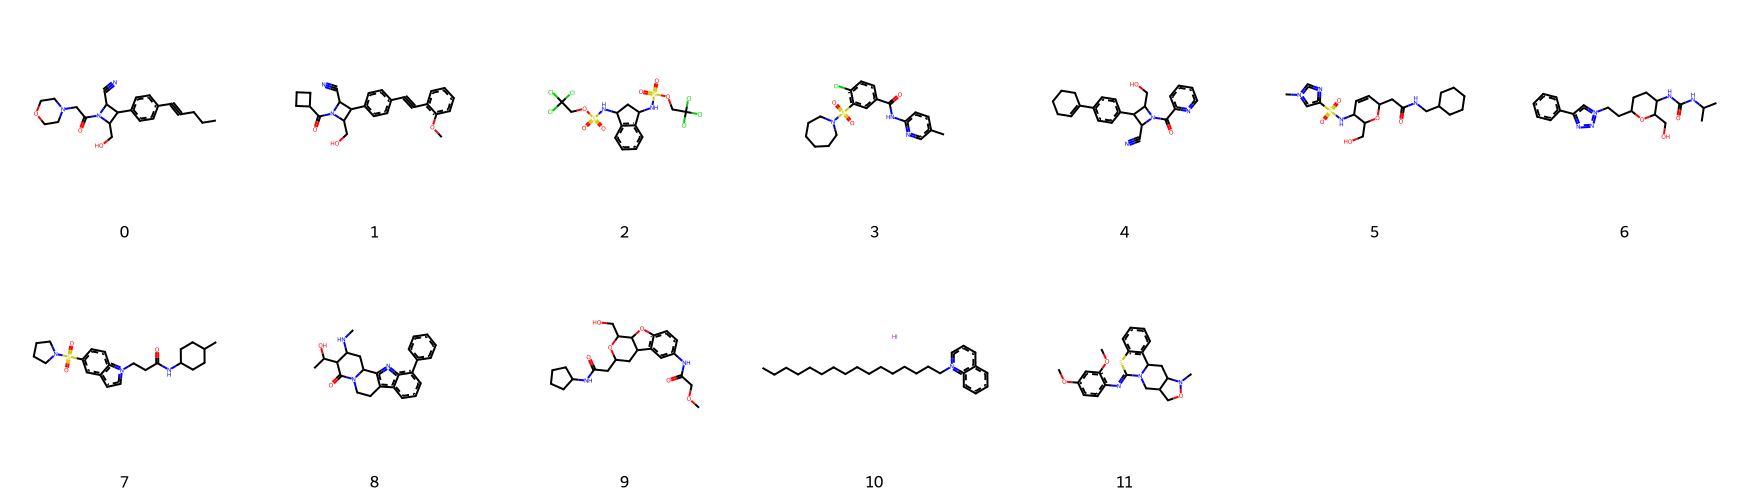

train_graphs=21 test_graphs=7


In [3]:
# Load and split the molecular dataset used by the chemistry demo.
from coco_grape.data_loader.loader import SupervisedDataSetLoader
from coco_grape.data_loader.mol.mol_loader import PubChemLoader
from sklearn.model_selection import train_test_split
ASSAY_ID = '651610'
DATASET_SIZE = 100
MAX_NODE_COUNT = 30
TEST_SIZE = 7
RANDOM_STATE = 42
DEBUG_MODE = False
DEBUG_TRAIN_SUBSET = 64
DEBUG_TEST_SUBSET = 16
PUBCHEM_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'PUBCHEM'

def load_pubchem_dataset(assay_id=ASSAY_ID, dataset_size=DATASET_SIZE, max_node_count=MAX_NODE_COUNT):
    loader = PubChemLoader()
    loader.pubchem_dir = str(PUBCHEM_DATA_ROOT)

    def pubchem_loader():
        return loader.load(assay_id, dirname=str(PUBCHEM_DATA_ROOT))

    original_graphs, original_targets = SupervisedDataSetLoader(
        pubchem_loader,
        size=dataset_size,
        use_equalized=False,
    ).load()
    original_graphs = np.asarray(original_graphs, dtype=object)
    original_targets = np.asarray(original_targets)
    keep = np.array([graph.number_of_nodes() <= max_node_count for graph in original_graphs], dtype=bool)
    graphs = original_graphs[keep].tolist()
    targets = original_targets[keep]
    return graphs, targets

graphs, targets = load_pubchem_dataset()
print(f"PubChem data root: {PUBCHEM_DATA_ROOT}")
summarize_graphs(graphs, targets, prefix="pubchem")
show_molecules(graphs, n=12, title="Example training molecules")
train_graphs, test_graphs, train_targets, test_targets = train_test_split(
    graphs,
    targets,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=targets,
)
print(f"train_graphs={len(train_graphs)} test_graphs={len(test_graphs)}")
if DEBUG_MODE:
    rng = np.random.default_rng(RANDOM_STATE)
    train_idx = rng.choice(len(train_graphs), size=min(DEBUG_TRAIN_SUBSET, len(train_graphs)), replace=False)
    test_idx = rng.choice(len(test_graphs), size=min(DEBUG_TEST_SUBSET, len(test_graphs)), replace=False)
    train_graphs = [train_graphs[int(i)] for i in train_idx]
    test_graphs = [test_graphs[int(i)] for i in test_idx]
    train_targets = np.asarray(train_targets)[train_idx]
    test_targets = np.asarray(test_targets)[test_idx]
    print(f"DEBUG_MODE active: train_graphs={len(train_graphs)} test_graphs={len(test_graphs)}")
    show_molecules(train_graphs, n=12, title="Debug subset training molecules")


## Model

This configuration is explicitly chemistry-oriented:
- `use_edges_as_features=True` so molecular bond labels are encoded,
- `lambda_edge_label_importance` is non-zero so bond labels are learned,
- `lambda_node_exist_importance` is non-zero so variable-size generation uses the predicted node mask,
- the full lambda surface is written out explicitly so additional consistency losses can be tuned in one place.

In [4]:
# Configure and build the chemistry-oriented graph generator.
try:
    from notebooks.demo_pipeline_utils import build_graph_generator
except ModuleNotFoundError:
    from demo_pipeline_utils import build_graph_generator

try:
    from notebooks.notebook_utils import (
        sample_positive_endpoint_pair,
        save_graph_generator,
        load_graph_generator,
        list_saved_graph_generators,
    )
except ModuleNotFoundError:
    from notebook_utils import (
        sample_positive_endpoint_pair,
        save_graph_generator,
        load_graph_generator,
        list_saved_graph_generators,
    )

NBITS = 11
VERBOSE = 2
APPLY_FEASIBILITY_FILTERING = False
SAVED_GENERATOR_ROOT = ARTIFACT_ROOT / 'saved_generators'

graph_generator = build_graph_generator(
    nbits=NBITS,
    verbose=VERBOSE,

    # Model architecture
    latent_embedding_dimension=128,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    transformer_dropout=0.15,

    # Optimization and stopping
    learning_rate=2e-4,
    maximum_epochs=200,
    batch_size=16,
    total_steps=100,
    verbose_epoch_interval=10,
    enable_early_stopping=True,
    early_stopping_monitor="val_total",
    early_stopping_mode="min",
    early_stopping_patience=30,
    early_stopping_min_delta=10.0,
    restore_best_checkpoint=True,

    # Loss weights
    lambda_direct_edge_importance=2e3,
    lambda_auxiliary_edge_importance=1e3,
    lambda_degree_importance=1e3,
    lambda_degree_edge_consistency_importance=5e2,
    lambda_node_exist_importance=1e3,
    lambda_node_count_importance=5e2,
    lambda_node_label_importance=1e3,
    lambda_edge_label_importance=2e3,
    lambda_edge_count_importance=1e3,

    # Sampling
    degree_temperature=1.0,
    node_field_sigma=0.2,
    sampling_step_size=0.05,
    langevin_noise_scale=0.0,

    # Locality and feasibility
    locality_sample_fraction=0.5,
    locality_horizon=1,
    negative_sample_factor=1,
    locality_sampling_strategy="stratified_preserve",
    locality_target_positive_ratio=0.5,
    max_feasibility_attempts=5,
    feasibility_candidates_per_attempt=16,
    feasibility_failure_mode="return_partial",

    # Decoder
    decoder_enforce_connectivity=True,
    decoder_warm_start_mst=True,
    decoder_n_jobs=4,

    # Artifacts
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
)


## Fit

Fitting the graph generator now plans and trains four relevant supervision channels for chemistry:
- node labels,
- edge labels,
- direct edge presence,
- auxiliary locality.

The Conditional Node Field model also receives the per-graph `node_presence_mask`, which is what lets it generate variable-size molecular graphs.

Fitting model on 21 graphs
Fitting feasibility estimator on 21 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 6 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 3552 pairs (50.00%) from 7104 total pairs (pos=2368, neg=4736, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=1184, neg=2368, positive_ratio=0.333.
Training conditional model on 21 graphs with up to 30 nodes each.
Using direct-edge supervision with 3552 labelled pairs.
Lambda settings: degree=1000.000, node_exist=1000.000, node_count=500.000, node_label=1000.000, edge_label=2000.000, direct_edge=2000.000, edge_c

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 10/200 | ETA 0h 04m 11s:
  train total=  73454.5 | node_field   51261.4 [69.8%] |        deg    1309.9 [1.8%] |      exist     113.0 [0.2%] | node_count     661.3 [0.9%]
  val   total=  83196.1 | node_field   51214.0 [61.6%] |        deg    1147.6 [1.4%] |      exist      94.2 [0.1%] | node_count     381.9 [0.5%]
  train                 | node_label    1208.8 [1.6%] | edge_label    1847.3 [2.5%] |       edge    4320.2 [5.9%] | edge_count   12206.3 [16.6%] | deg_edge_consistency     526.3 [0.7%] | dominant=node_field [69.8%]
  val                   | node_label    1047.2 [1.3%] | edge_label    2207.5 [2.7%] |       edge    2614.5 [3.1%] | edge_count   24301.2 [29.2%] | deg_edge_consistency     188.0 [0.2%] | dominant=node_field [61.6%]
Epoch 20/200 | ETA 0h 04m 25s:
  train total=  65090.1 | node_field   51172.5 [78.6%] |        deg    1232.9 [1.9%] |      exist     157.1 [0.2%] | node_count     571.5 [0.9%]
  val   total=  67208.1 | node_field   51378.7 [76.4%] |        deg    11

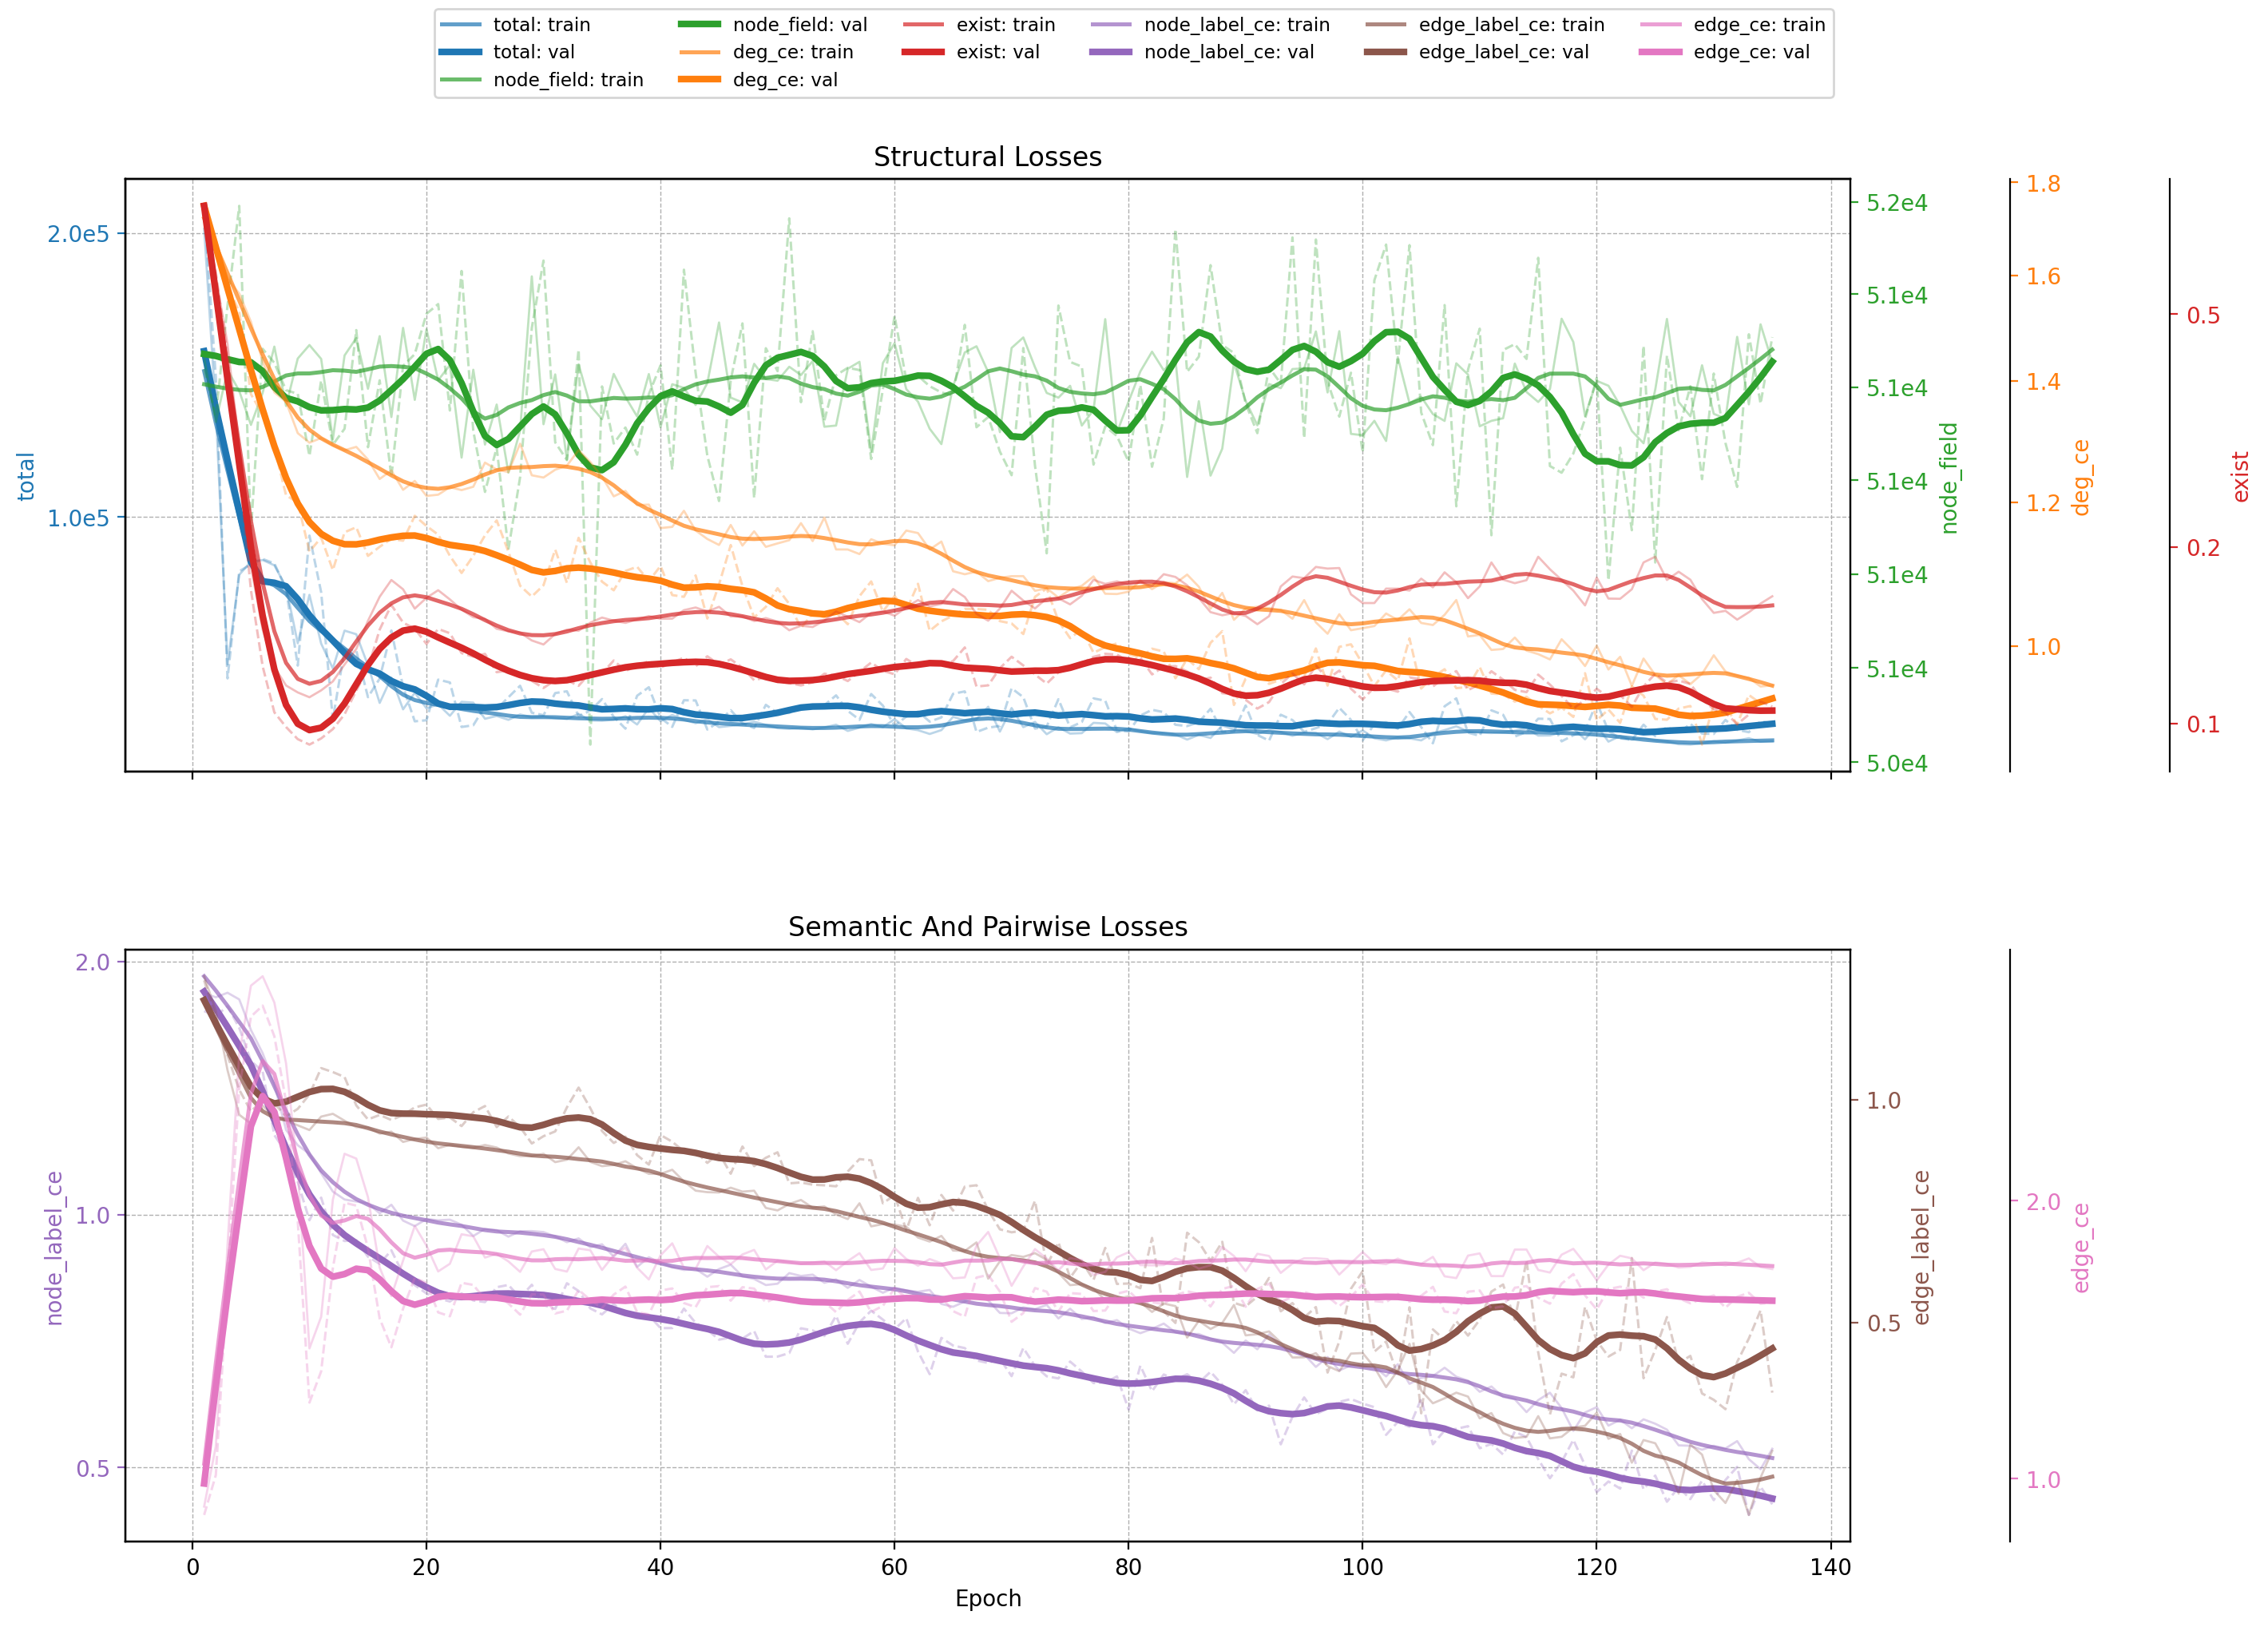

Restored best checkpoint: best_epoch=105, val_total=57529.5195, raw_val_node_field=51145.3945, stopped_epoch=136
  path=/Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/node_field/ConditionalNodeFieldGenerator_f3f132690bb2493ebf97ae7023a76b10/best-104-57529.5195.ckpt
CPU times: user 21min 16s, sys: 2min 29s, total: 23min 45s
Wall time: 3min 31s


In [5]:
%%time
graph_generator.fit(train_graphs)


## Save Or Resume The Fitted Chemistry Generator

Saved generator filenames are intentionally short so you can copy them into a later session. This notebook uses the current Conditional Node Field artifact format.
Persist the fitted generator once, copy the printed short filename, and later reload it without retraining.


In [6]:
# Save the fitted chemistry generator and print a short filename for later reuse.
MODEL_FILENAME = save_graph_generator(
    graph_generator,
    model_name='demo-chem',
    model_dir=SAVED_GENERATOR_ROOT,
)
MODEL_FILENAME


Saved graph generator as: demo-chem-20260307-2211-c1290e.pkl
/Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_generators/demo-chem-20260307-2211-c1290e.pkl


'demo-chem-20260307-2211-c1290e.pkl'

In [7]:
# Resume later with a copied filename from the save cell.
if False:
    list_saved_graph_generators(SAVED_GENERATOR_ROOT)
    MODEL_FILENAME = 'demo-chem-20260307-1702-f973fb.pkl'
    graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


## Inspect Masking And Bond Labels

Before decoding, inspect the latent predictions directly.

This is the part that matters for the current chemistry setup:
- `node_presence_mask` controls the generated number of atoms,
- `edge_label_matrices` provide predicted bond labels for the decoder.

,conditioning_nodes,predicted_nodes,conditioning_edges
0,24,30,26
1,29,30,30
2,24,30,25
3,29,30,31
4,30,30,32
5,23,30,25


,graph_idx,1,2,AROMATIC
0,0,649,51,200
1,1,558,23,319
2,2,632,95,173
3,3,631,7,262
4,4,786,1,113
5,5,758,44,98


Decoded molecules from the inspected latent batch


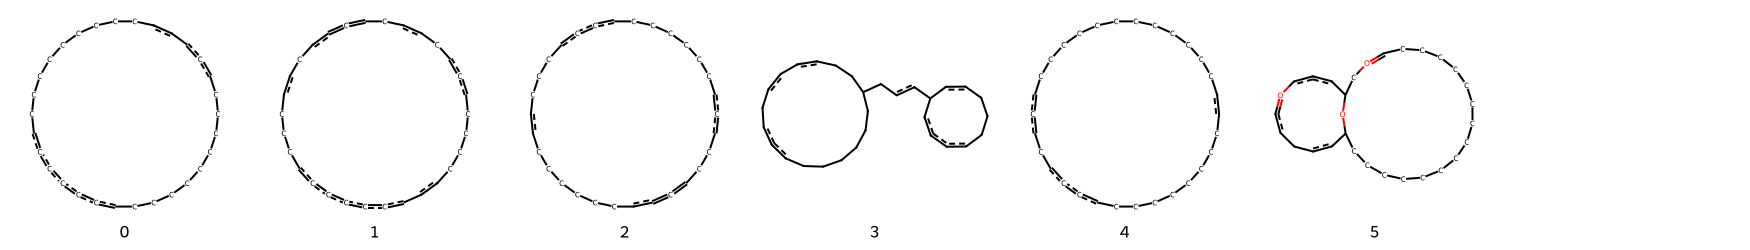

In [8]:
# Inspect predicted node masks and bond-label logits before full decoding.
inspected_nodes, inspected_graphs = inspect_predicted_masks_and_edge_labels(
    graph_generator,
    train_graphs[:6],
    n_graphs=6,
)

## Conditional Molecule Sampling

The sampling examples below condition on real molecules and draw the generated molecules with the chemistry-specific routines.

Raw decoded molecules without feasibility filtering


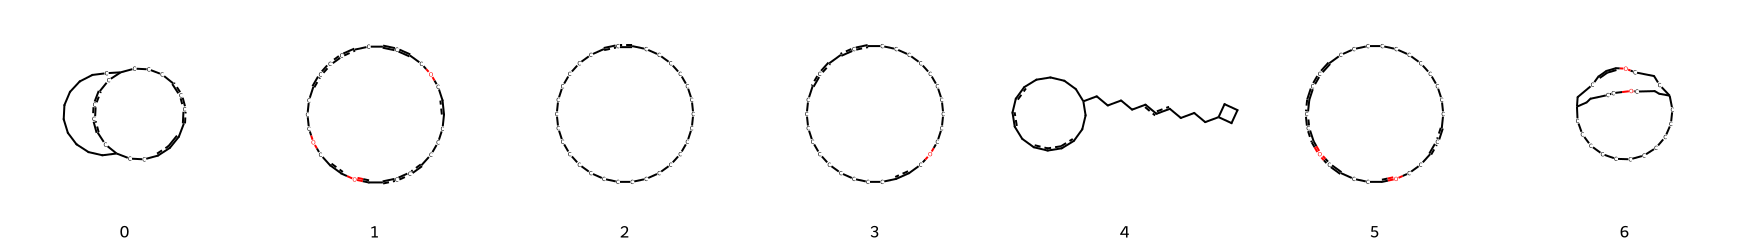

In [9]:
# Generate raw conditional samples from held-out molecules.
raw_samples = graph_generator.sample_conditioned_on_random(
    test_graphs,
    n_samples=7,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)
show_molecules(raw_samples, n=8, title="Raw decoded molecules without feasibility filtering")

### Seed vs Sample Comparison
Show each seed molecule next to generated variants so feasibility filtering is easy to inspect.


Held-out conditioning set: conditioning molecules


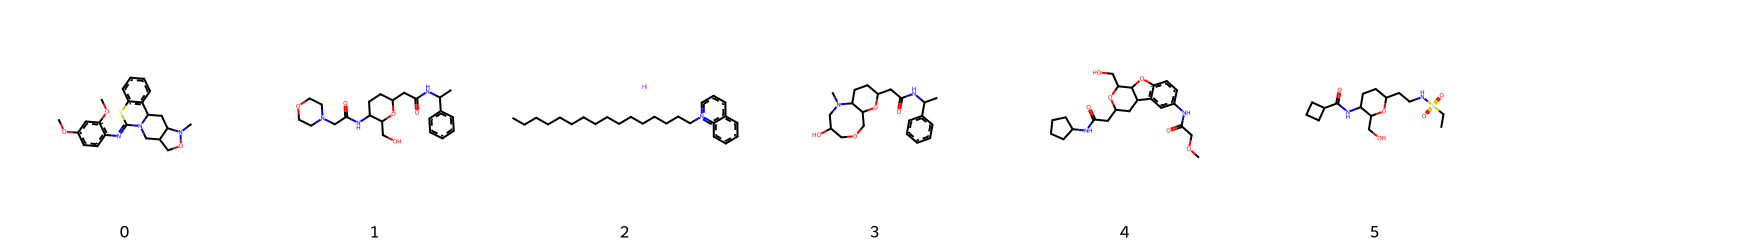

Held-out conditioning set: generated molecules without feasibility


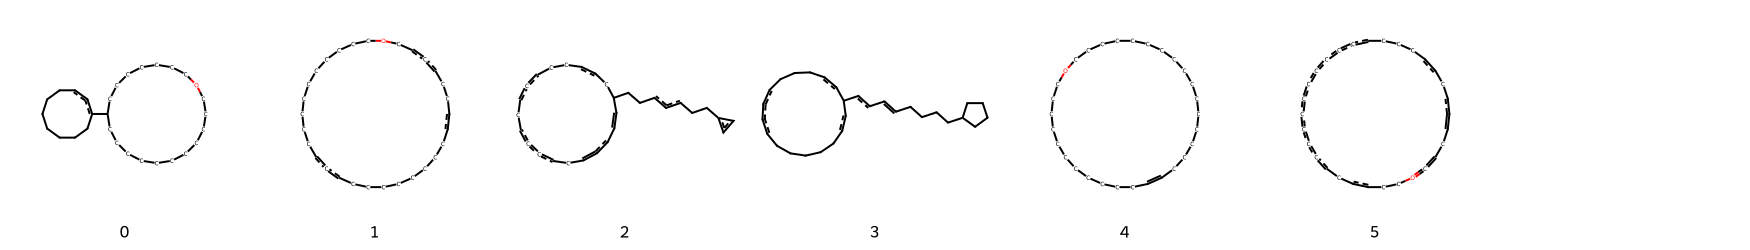

In [10]:
# Show the seed molecules next to unfiltered and feasibility-filtered samples.
show_seed_and_samples(
    graph_generator,
    test_graphs,
    n_seeds=6,
    title="Held-out conditioning set",
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)

Active class: conditioning molecules


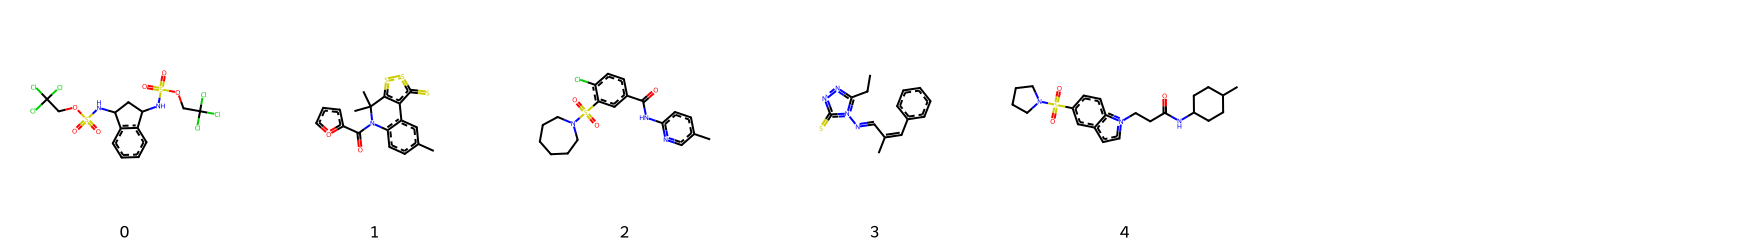

Active class: generated molecules without feasibility


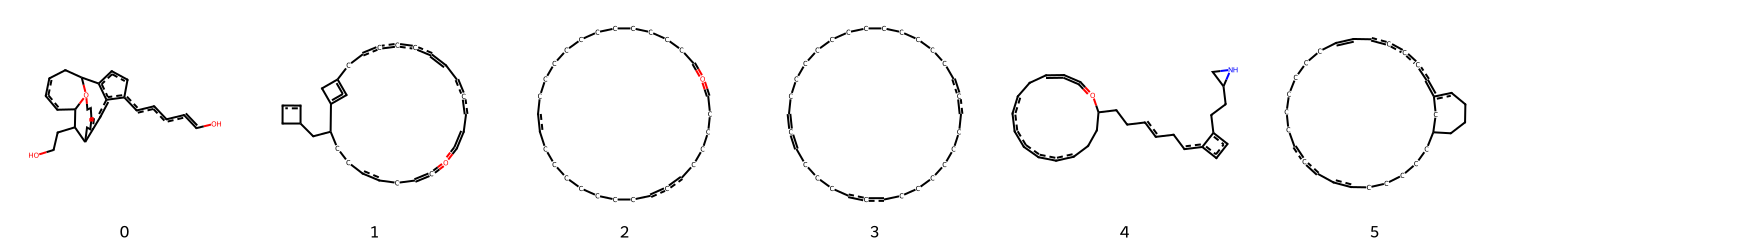

Inactive class: conditioning molecules


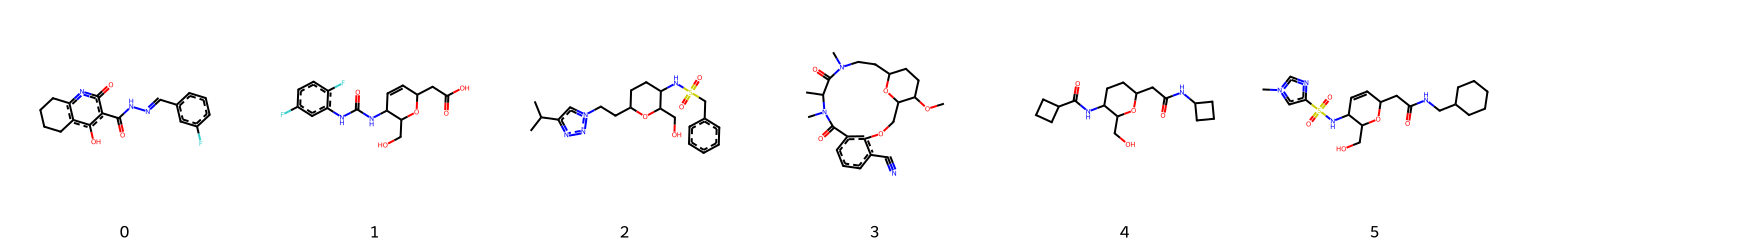

Inactive class: generated molecules without feasibility


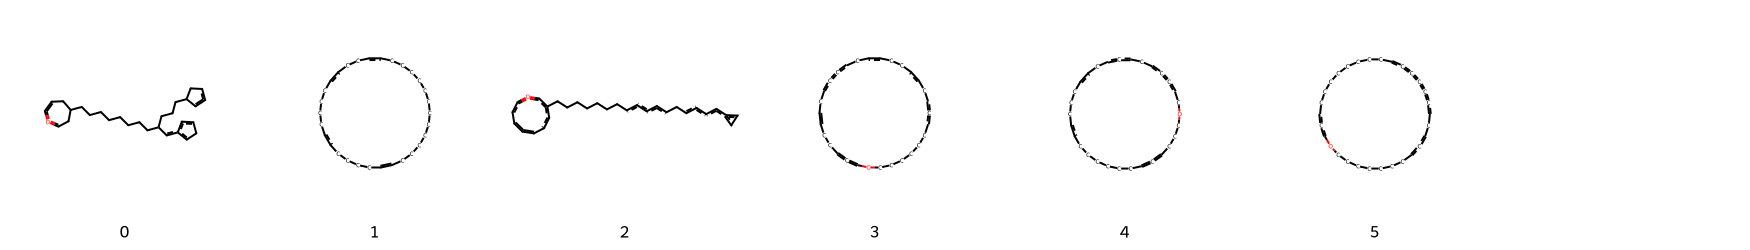

In [11]:
# Compare active and inactive seed groups side by side.
active_seed_graphs = [graph for graph, target in zip(train_graphs, train_targets) if target == 1]
inactive_seed_graphs = [graph for graph, target in zip(train_graphs, train_targets) if target == 0]

active_samples = show_seed_and_samples(
    graph_generator,
    active_seed_graphs,
    n_seeds=6,
    title="Active class",
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)

inactive_samples = show_seed_and_samples(
    graph_generator,
    inactive_seed_graphs,
    n_seeds=6,
    title="Inactive class",
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)

### Active vs Inactive Seed Groups
Contrast sampling behavior for positive and negative chemistry seeds.


## Positive Endpoint Interpolation

Select two active molecules at random, interpolate between them, and display the endpoints plus feasible generated molecules.

Endpoint indices: [20, 16]
Endpoint targets: [1, 1]
Selected endpoint molecules


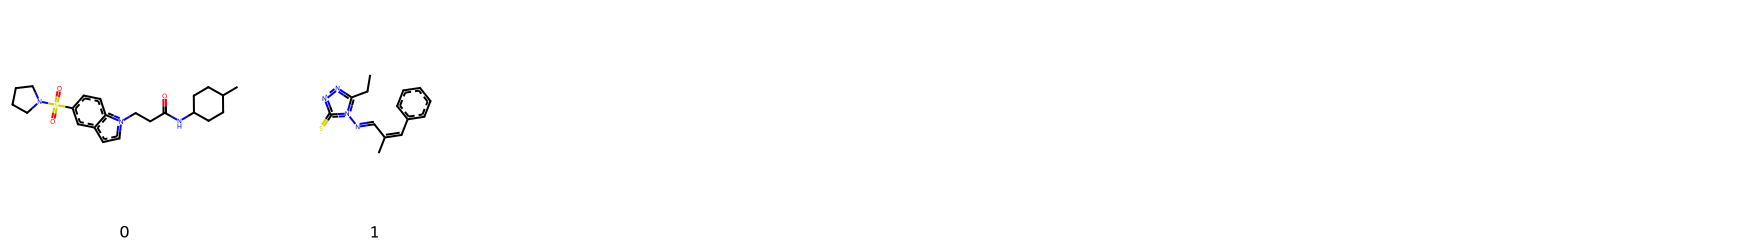

In [ ]:
# Interpolate between two active molecules and decode the intermediate trajectory.
selected_indices, selected_targets, endpoint_graph_a, endpoint_graph_b = sample_positive_endpoint_pair(
    train_graphs,
    train_targets,
)
print("Endpoint indices:", selected_indices)
print("Endpoint targets:", selected_targets)

show_molecules([endpoint_graph_a, endpoint_graph_b], n=2, title="Selected endpoint molecules")

interpolation_result = graph_generator.interpolate(
    endpoint_graph_a,
    endpoint_graph_b,
    k=3,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)
display(interpolation_result["summary"])

missing_steps = interpolation_result["summary"].loc[
    ~interpolation_result["summary"]["decoded"],
    "step",
].tolist()
if missing_steps:
    print("Interpolation steps rejected by feasibility filtering:", missing_steps)

show_molecules(
    [endpoint_graph_a, *interpolation_result["generated_graphs"], endpoint_graph_b],
    n=len(interpolation_result["generated_graphs"]) + 2,
    title="Endpoints and generated interpolation molecules",
)


## Stochastic Training-Embedding Sampling

Sample new graph-level conditioning vectors by interpolating between pairs of cached training embeddings, then decode and display the resulting molecules.

In [ ]:
# Sample fresh graph-level conditions from cached training embeddings and decode them.
interpolated_samples = graph_generator.sample(
    n_samples=7*4,
    interpolate_between_n_samples=10,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)

print("Feasible stochastic interpolation samples:", len(interpolated_samples))
show_molecules(
    interpolated_samples,
    title="Samples from stochastic training-embedding interpolation",
)
